# Word Frequency Analysis — TRIGGERnometry

Neutral frequency analysis across three text sources:

1. **Titles** — short, keyword-dense, reveal editorial framing  
2. **Descriptions** — longer-form, contain guest context and topic cues  
3. **Cumulative** — combined title + description corpus

All analyses use standard NLP pre-processing (lowercasing, stopword removal, tokenisation).  
No political labels or sentiment scores are assigned here — this is purely descriptive.

In [1]:
import re
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

## 0 — Load data & preprocessing helpers

In [2]:
DATA_PATH = "../../../../data/TRIGGERnometry-video-taxonomy/trigggerpod.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["published_date"])
df = df.sort_values("published_date").reset_index(drop=True)

print(f"Videos: {len(df):,}")
print(f"Date range: {df['published_date'].min().date()} → {df['published_date'].max().date()}")

Videos: 1,849
Date range: 2018-04-23 → 2026-03-01


In [3]:
STOP_WORDS = set(stopwords.words("english"))

# Channel-specific boilerplate tokens that appear in nearly every description
# and add no analytical value
CHANNEL_BOILERPLATE = {
    "triggernometry", "triggerpod", "trigger", "https", "http", "www",
    "com", "youtube", "twitter", "facebook", "instagram", "patreon",
    "subscribestar", "substack", "subscribe", "subscribers",
    "konstantin", "kisin", "konstantinkisin", "francis", "foster",
    "failinghuman", "join", "support", "mission", "content",
    "visit", "find", "us", "social", "media", "amazing",
    "journey", "million", "paypal", "cgi", "bin", "webscr",
    "hosted", "button", "url", "source", "cmd", "xclick",
    "co", "uk", "org", "watch", "channel",
}

ALL_STOPS = STOP_WORDS | CHANNEL_BOILERPLATE

# URL regex for stripping links from descriptions
URL_RE = re.compile(r"https?://\S+")


def clean_text(text: str) -> str:
    """Lowercase, strip URLs, keep only alphabetic tokens."""
    text = URL_RE.sub("", text)
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return text


def tokenize(text: str) -> list[str]:
    """Tokenize and remove stopwords + boilerplate."""
    tokens = word_tokenize(clean_text(text))
    return [t for t in tokens if len(t) > 2 and t not in ALL_STOPS]


# Pre-compute token lists
df["title_tokens"] = df["title"].fillna("").apply(tokenize)
df["desc_tokens"] = df["description"].fillna("").apply(tokenize)
df["combined_tokens"] = df["title_tokens"] + df["desc_tokens"]

print("Tokenisation complete.")
print(f"  Title tokens (total):       {df['title_tokens'].str.len().sum():,}")
print(f"  Description tokens (total):  {df['desc_tokens'].str.len().sum():,}")
print(f"  Combined tokens (total):     {df['combined_tokens'].str.len().sum():,}")

Tokenisation complete.
  Title tokens (total):       9,445
  Description tokens (total):  116,818
  Combined tokens (total):     126,263


---

## 1 — Title word frequency

In [4]:
title_freq = Counter(tok for tokens in df["title_tokens"] for tok in tokens)
title_top50 = title_freq.most_common(50)

print(f"Unique title tokens: {len(title_freq):,}")
pd.DataFrame(title_top50, columns=["token", "count"]).head(20)

Unique title tokens: 3,126


,token,count
0,shorts,138
1,culture,77
2,politics,75
3,truth,58
4,war,56
5,trump,52
6,women,51
7,live,50
8,trans,49
9,andrew,47


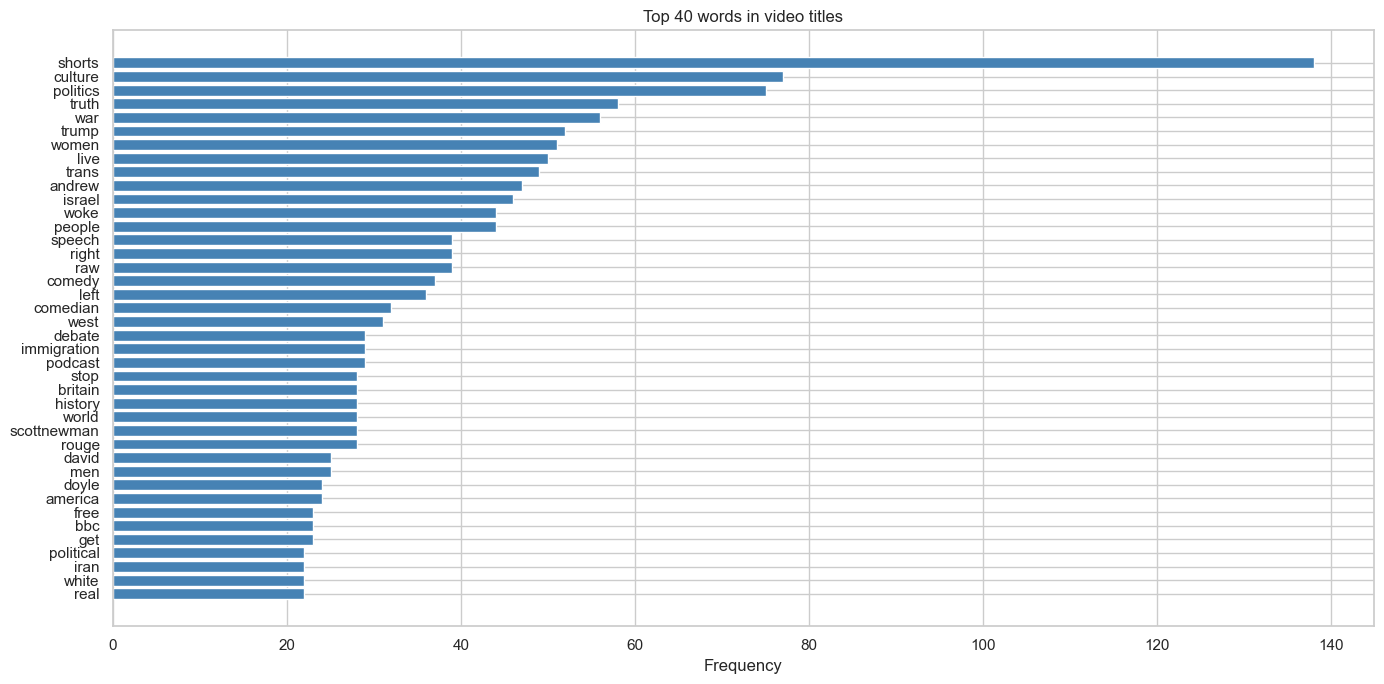

In [5]:
# Bar chart — top 40 title words
words, counts = zip(*title_freq.most_common(40))

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(range(len(words)), counts, color="steelblue")
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
ax.invert_yaxis()
ax.set_xlabel("Frequency")
ax.set_title("Top 40 words in video titles")
plt.tight_layout()
plt.show()

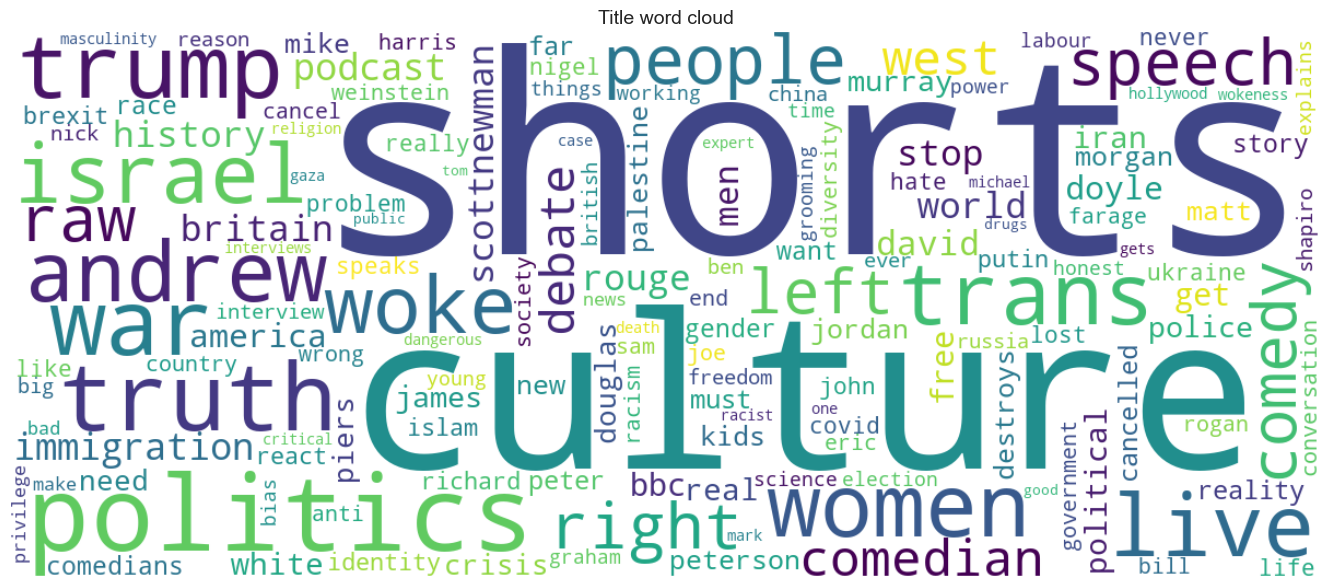

In [6]:
# Word cloud — titles
wc = WordCloud(width=1200, height=500, background_color="white",
               colormap="viridis", max_words=150)
wc.generate_from_frequencies(title_freq)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Title word cloud", fontsize=14)
plt.tight_layout()
plt.show()

### 1b — Title bigrams

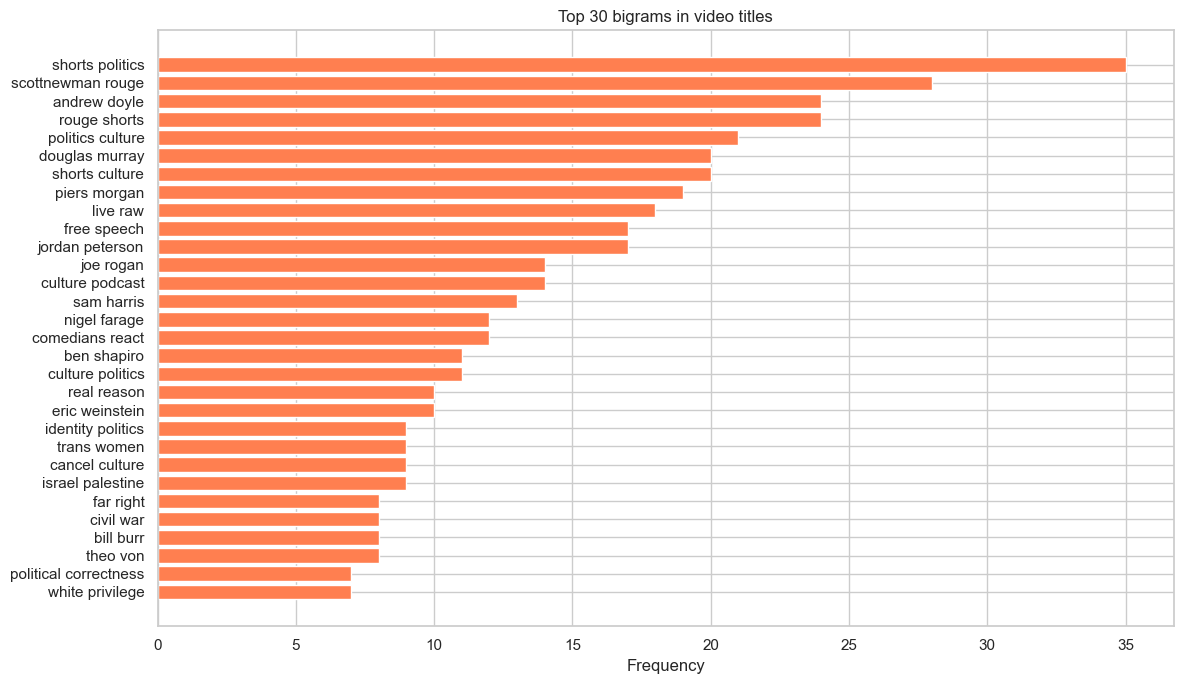

In [7]:
from nltk import bigrams as nltk_bigrams

title_bigrams = Counter()
for tokens in df["title_tokens"]:
    title_bigrams.update(nltk_bigrams(tokens))

top_bi = title_bigrams.most_common(30)
labels = [f"{a} {b}" for (a, b), _ in top_bi]
values = [c for _, c in top_bi]

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(range(len(labels)), values, color="coral")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Frequency")
ax.set_title("Top 30 bigrams in video titles")
plt.tight_layout()
plt.show()

---

## 2 — Description word frequency

In [8]:
desc_freq = Counter(tok for tokens in df["desc_tokens"] for tok in tokens)
desc_top50 = desc_freq.most_common(50)

print(f"Unique description tokens: {len(desc_freq):,}")
pd.DataFrame(desc_top50, columns=["token", "count"]).head(20)

Unique description tokens: 8,540


,token,count
0,comedians,3281
1,free,2076
2,politics,1928
3,speech,1739
4,community,1692
5,stand,1682
6,help,1681
7,make,1671
8,exclusive,1671
9,controversial,1668


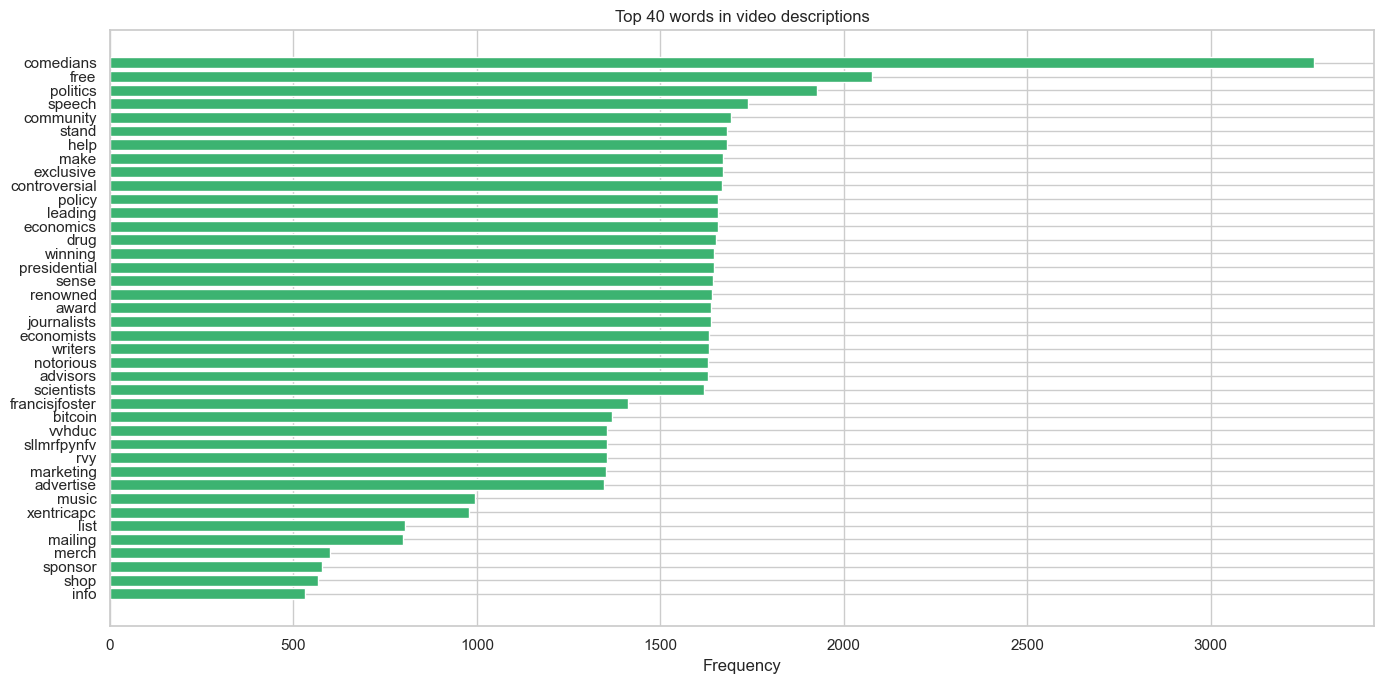

In [9]:
words, counts = zip(*desc_freq.most_common(40))

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(range(len(words)), counts, color="mediumseagreen")
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
ax.invert_yaxis()
ax.set_xlabel("Frequency")
ax.set_title("Top 40 words in video descriptions")
plt.tight_layout()
plt.show()

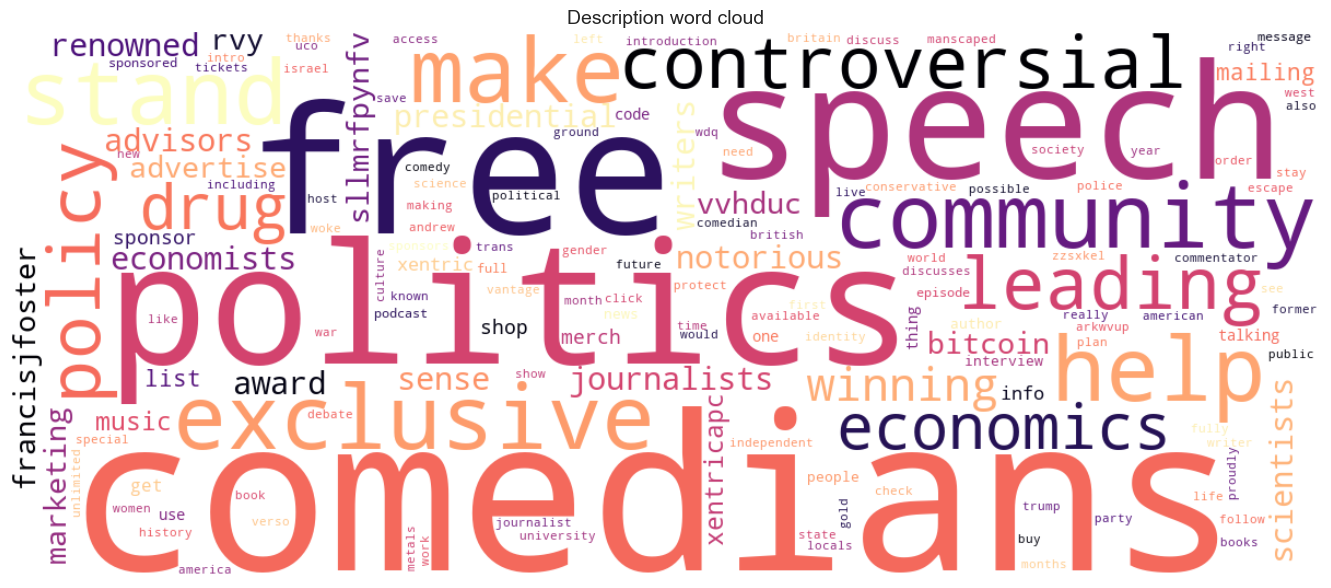

In [10]:
wc_desc = WordCloud(width=1200, height=500, background_color="white",
                    colormap="magma", max_words=150)
wc_desc.generate_from_frequencies(desc_freq)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc_desc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Description word cloud", fontsize=14)
plt.tight_layout()
plt.show()

### 2b — Description bigrams

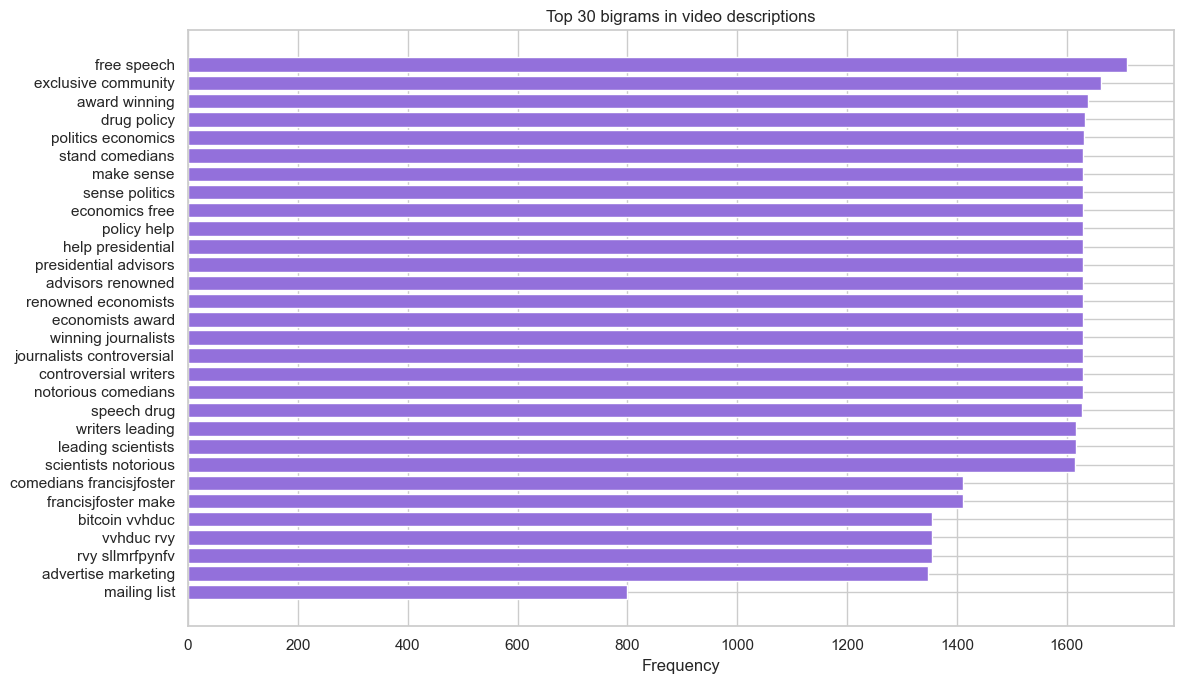

In [11]:
desc_bigrams = Counter()
for tokens in df["desc_tokens"]:
    desc_bigrams.update(nltk_bigrams(tokens))

top_bi_d = desc_bigrams.most_common(30)
labels_d = [f"{a} {b}" for (a, b), _ in top_bi_d]
values_d = [c for _, c in top_bi_d]

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(range(len(labels_d)), values_d, color="mediumpurple")
ax.set_yticks(range(len(labels_d)))
ax.set_yticklabels(labels_d)
ax.invert_yaxis()
ax.set_xlabel("Frequency")
ax.set_title("Top 30 bigrams in video descriptions")
plt.tight_layout()
plt.show()

---

## 3 — Cumulative (title + description) word frequency

Unique combined tokens: 8,994


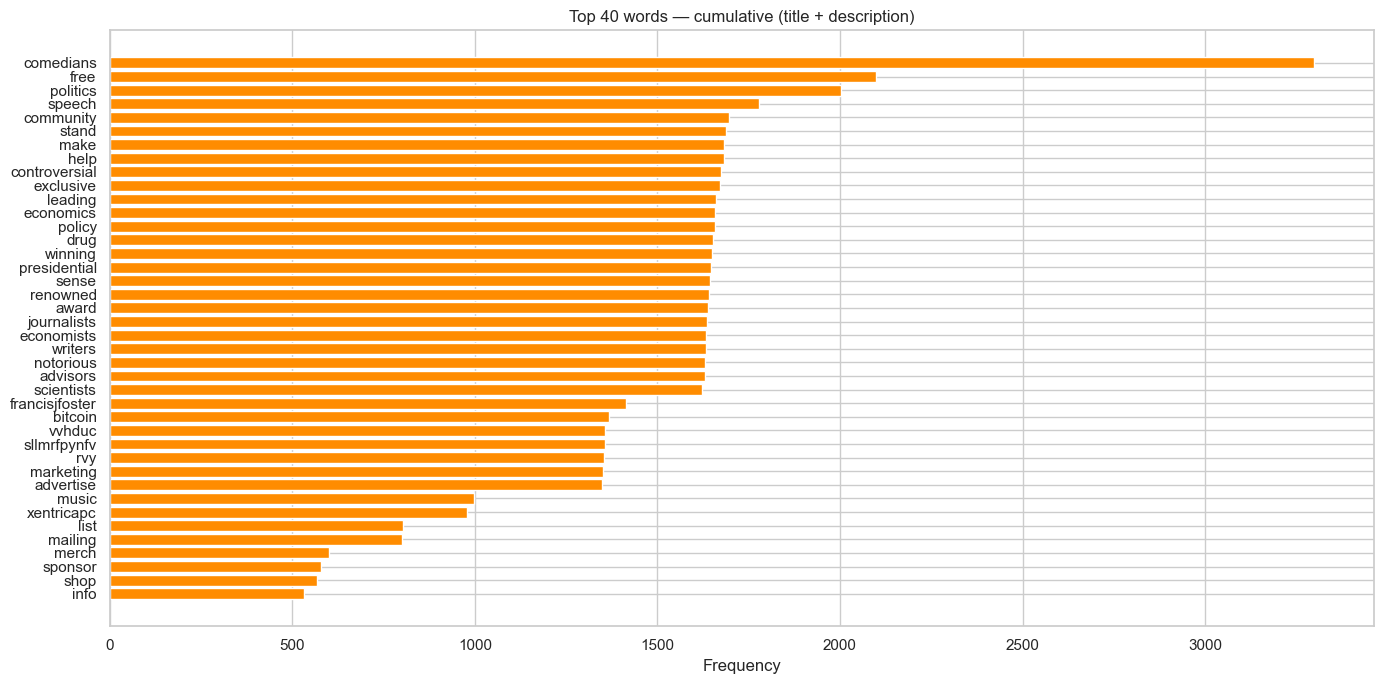

In [12]:
combined_freq = Counter(tok for tokens in df["combined_tokens"] for tok in tokens)

print(f"Unique combined tokens: {len(combined_freq):,}")

words_c, counts_c = zip(*combined_freq.most_common(40))

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(range(len(words_c)), counts_c, color="darkorange")
ax.set_yticks(range(len(words_c)))
ax.set_yticklabels(words_c)
ax.invert_yaxis()
ax.set_xlabel("Frequency")
ax.set_title("Top 40 words — cumulative (title + description)")
plt.tight_layout()
plt.show()

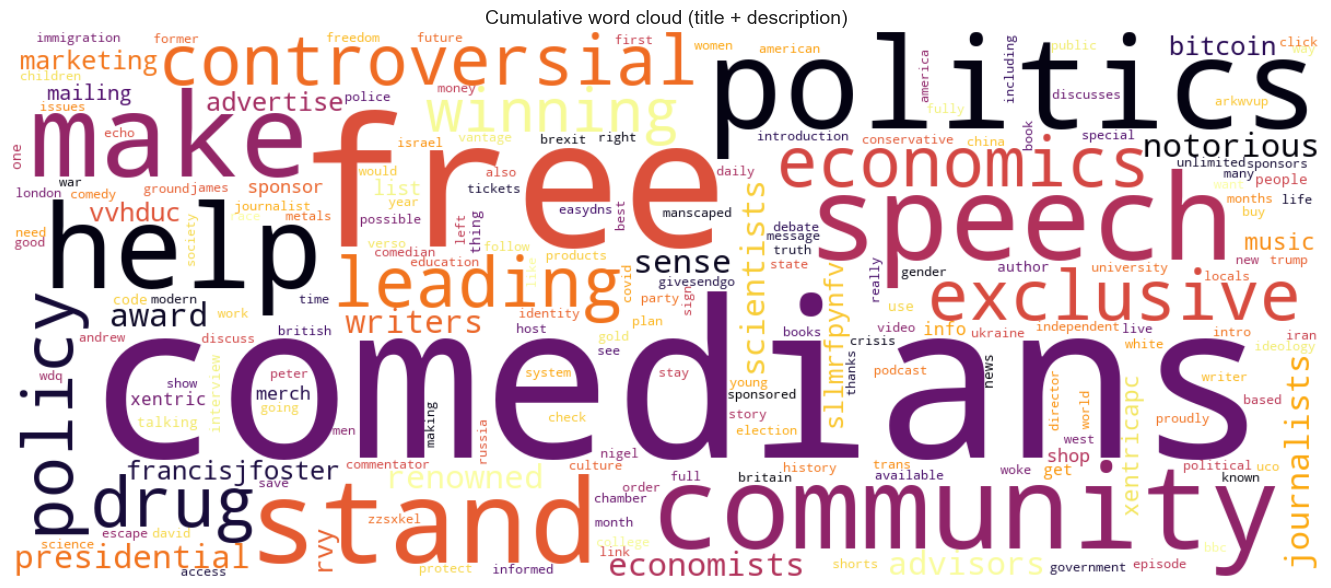

In [13]:
wc_comb = WordCloud(width=1200, height=500, background_color="white",
                    colormap="inferno", max_words=200)
wc_comb.generate_from_frequencies(combined_freq)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc_comb, interpolation="bilinear")
ax.axis("off")
ax.set_title("Cumulative word cloud (title + description)", fontsize=14)
plt.tight_layout()
plt.show()

### 3b — Side-by-side comparison: title vs description vocabulary

/var/folders/r9/gmqzlhhd67vdxkgnkq05lj6h0000gn/T/ipykernel_48736/4071423591.py:30: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/stats-notes-python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


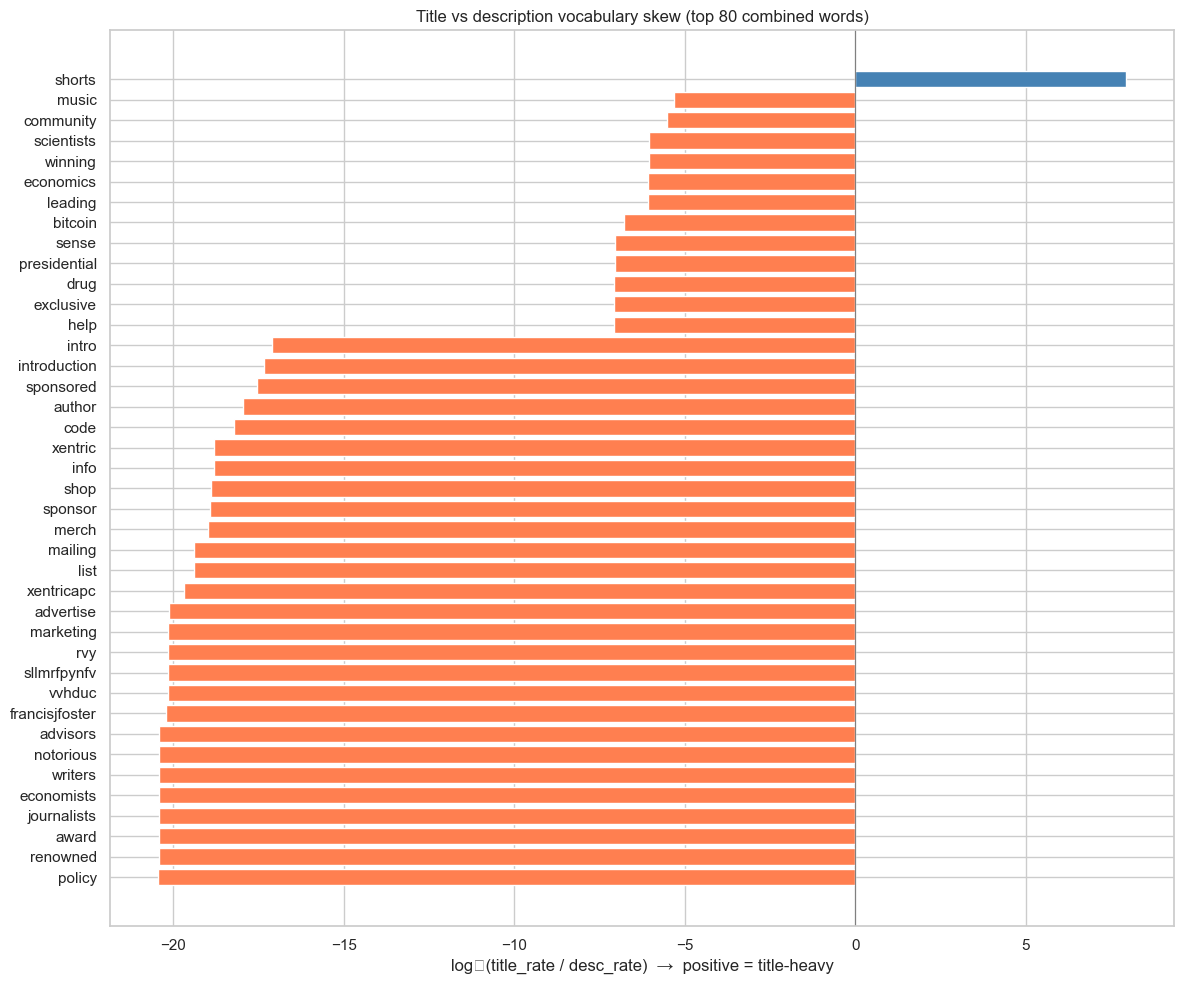

In [14]:
# Which words are disproportionately used in titles vs descriptions?
top_combined = [w for w, _ in combined_freq.most_common(80)]

title_total = sum(title_freq.values())
desc_total = sum(desc_freq.values())

comparison = pd.DataFrame({
    "token": top_combined,
    "title_freq": [title_freq[w] for w in top_combined],
    "desc_freq": [desc_freq[w] for w in top_combined],
})
comparison["title_rate"] = comparison["title_freq"] / title_total
comparison["desc_rate"] = comparison["desc_freq"] / desc_total
comparison["log_ratio"] = np.log2(
    (comparison["title_rate"] + 1e-8) / (comparison["desc_rate"] + 1e-8)
)

# Tokens most skewed toward titles vs descriptions
comparison_sorted = comparison.reindex(
    comparison["log_ratio"].abs().sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(12, 10))
top_skewed = comparison_sorted.head(40).sort_values("log_ratio")
colours = ["steelblue" if v > 0 else "coral" for v in top_skewed["log_ratio"]]
ax.barh(top_skewed["token"], top_skewed["log_ratio"], color=colours)
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_xlabel("log₂(title_rate / desc_rate)  →  positive = title-heavy")
ax.set_title("Title vs description vocabulary skew (top 80 combined words)")
plt.tight_layout()
plt.show()

---

## 4 — Temporal trends: word frequency over time

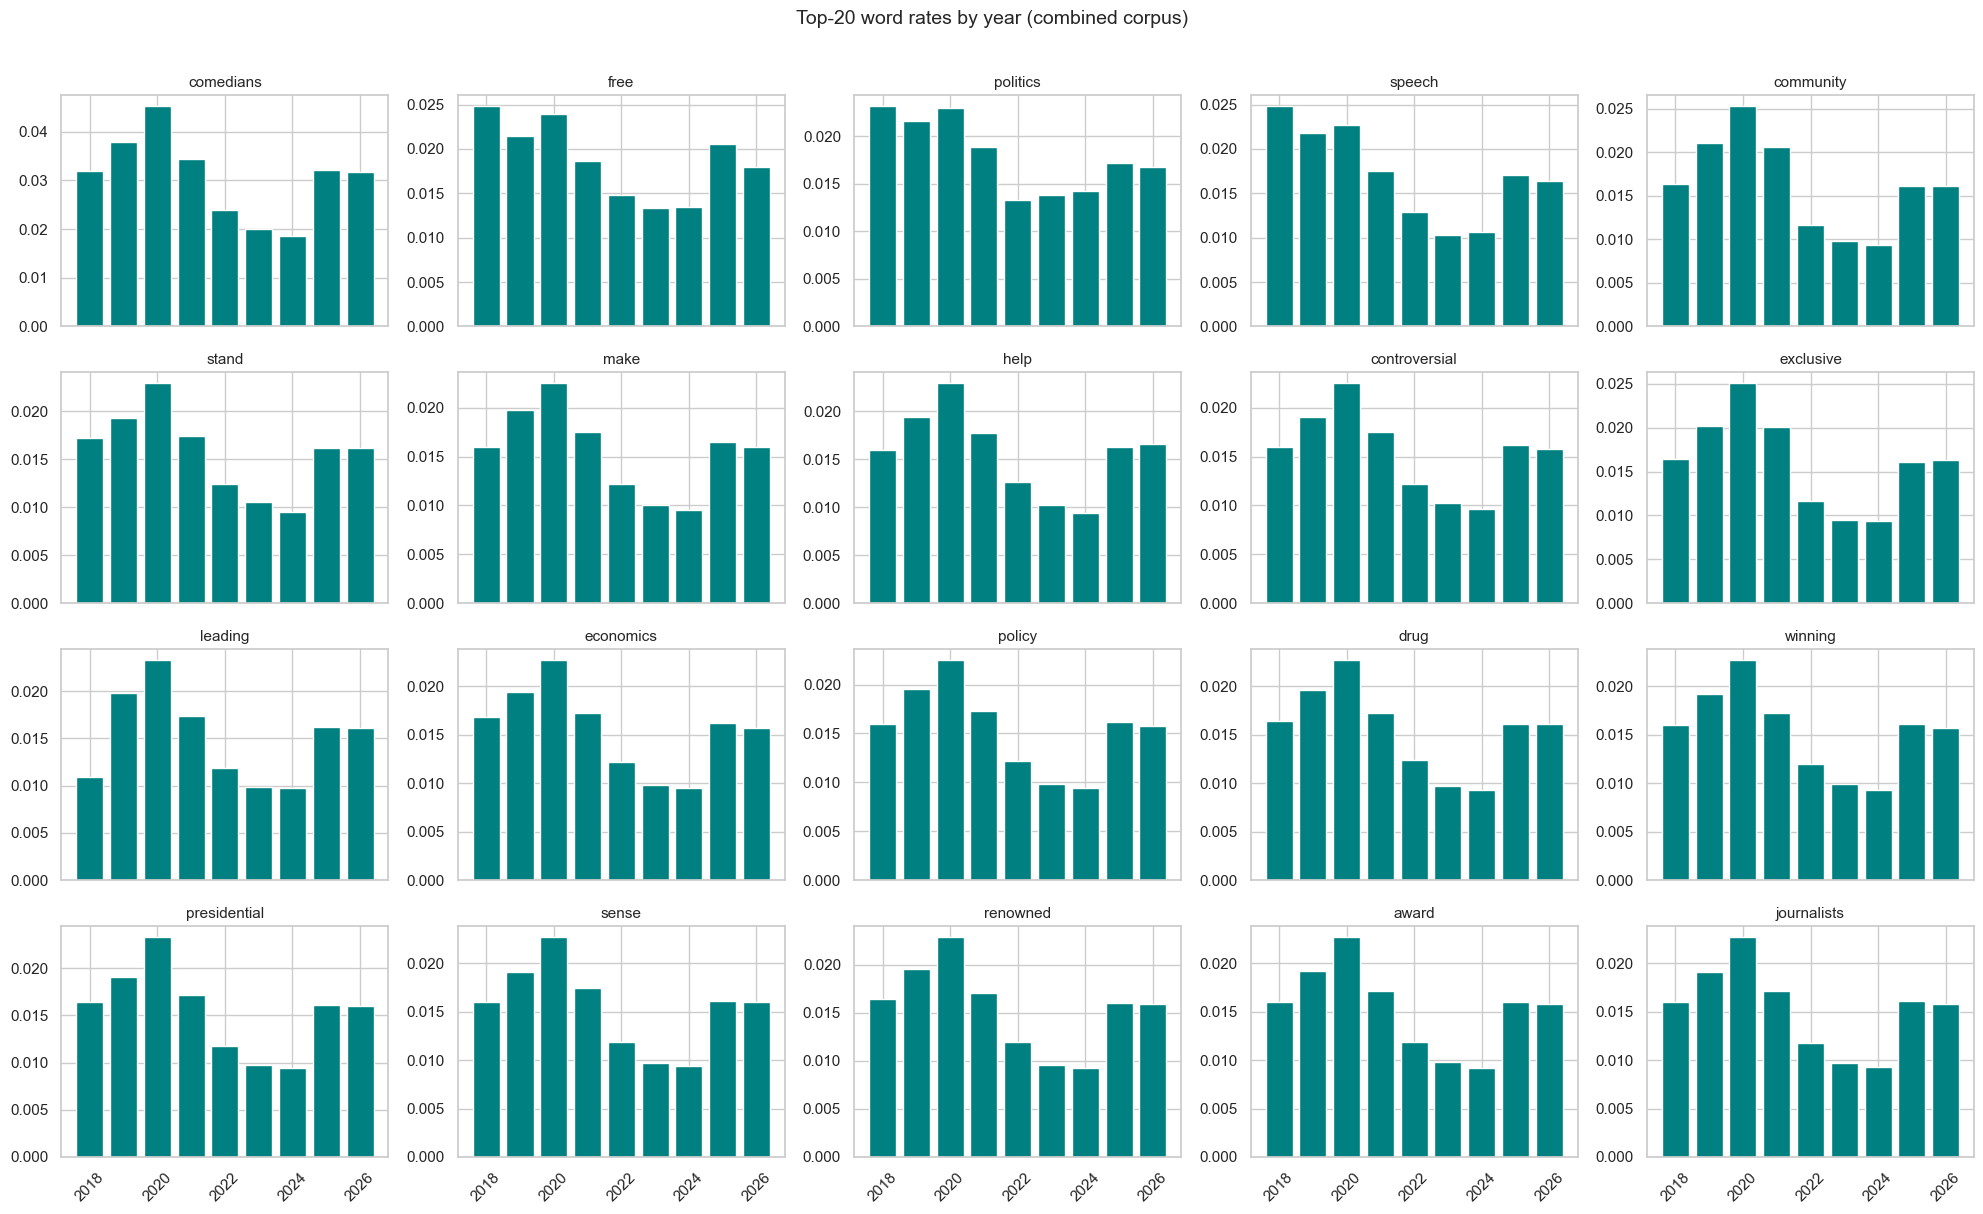

In [15]:
df["year"] = df["published_date"].dt.year

# Pick top-20 combined words and track yearly frequency
top20_words = [w for w, _ in combined_freq.most_common(20)]

yearly_word = []
for year, group in df.groupby("year"):
    year_tokens = [tok for tokens in group["combined_tokens"] for tok in tokens]
    year_total = len(year_tokens)
    year_counter = Counter(year_tokens)
    for w in top20_words:
        yearly_word.append({
            "year": year,
            "word": w,
            "count": year_counter[w],
            "rate": year_counter[w] / year_total if year_total else 0,
        })

yw = pd.DataFrame(yearly_word)

fig, axes = plt.subplots(4, 5, figsize=(20, 12), sharex=True)
for ax, word in zip(axes.flat, top20_words):
    subset = yw[yw["word"] == word]
    ax.bar(subset["year"], subset["rate"], color="teal")
    ax.set_title(word, fontsize=11)
    ax.tick_params(axis="x", rotation=45)
plt.suptitle("Top-20 word rates by year (combined corpus)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

---

## 5 — TF-IDF: distinctive words per year

In [16]:
# Build one "document" per year from combined tokens
year_docs = (
    df.groupby("year")["combined_tokens"]
    .apply(lambda s: " ".join(tok for tokens in s for tok in tokens))
)

tfidf = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf.fit_transform(year_docs)
feature_names = np.array(tfidf.get_feature_names_out())

print("Top TF-IDF terms per year:\n")
for idx, year in enumerate(year_docs.index):
    row = tfidf_matrix[idx].toarray().flatten()
    top_idx = row.argsort()[-15:][::-1]
    top_terms = feature_names[top_idx]
    top_scores = row[top_idx]
    terms_str = ", ".join(f"{t} ({s:.3f})" for t, s in zip(top_terms, top_scores))
    print(f"  {year}: {terms_str}")

Top TF-IDF terms per year:

  2018: comedians (0.288), free (0.224), speech (0.224), politics (0.209), guys (0.189), facilitate (0.189), discusses (0.170), stand (0.156), economics (0.152), open (0.149), community (0.148), presidential (0.148), drug (0.148), renowned (0.148), exclusive (0.148)
  2019: comedians (0.344), speech (0.198), politics (0.196), free (0.194), community (0.191), exclusive (0.183), make (0.179), leading (0.179), drug (0.178), renowned (0.178), policy (0.178), help (0.176), economics (0.176), winning (0.174), award (0.174)
  2020: comedians (0.363), community (0.203), exclusive (0.201), free (0.192), leading (0.187), presidential (0.187), renowned (0.184), stand (0.184), politics (0.184), help (0.184), journalists (0.182), award (0.182), sense (0.182), drug (0.182), speech (0.182)
  2021: comedians (0.298), mailing (0.211), list (0.190), francisjfoster (0.182), community (0.179), sllmrfpynfv (0.176), rvy (0.176), bitcoin (0.176), vvhduc (0.176), exclusive (0.174),

---

## 6 — Zipf's law check

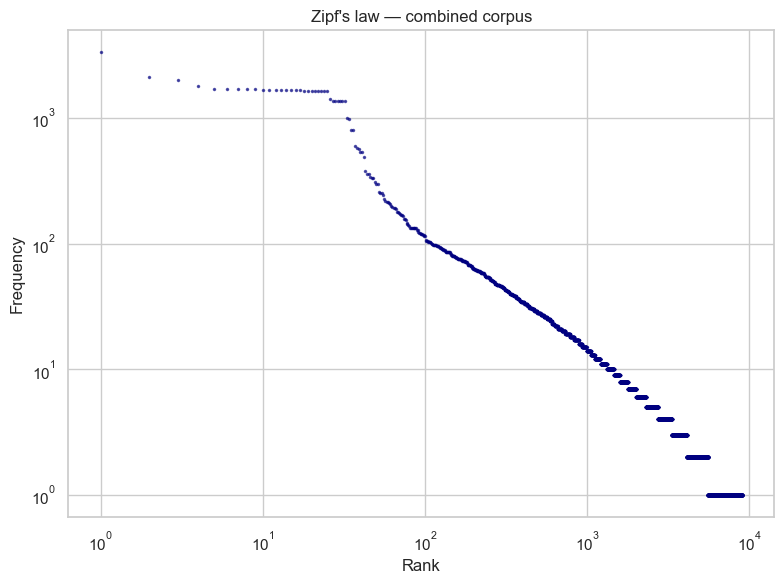

In [17]:
# Zipf plot for the combined corpus
ranks = np.arange(1, len(combined_freq) + 1)
freqs = sorted(combined_freq.values(), reverse=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(ranks, freqs, ".", markersize=3, alpha=0.6, color="navy")
ax.set_xlabel("Rank")
ax.set_ylabel("Frequency")
ax.set_title("Zipf's law — combined corpus")
plt.tight_layout()
plt.show()

---

## 7 — Hapax legomena & vocabulary richness

In [18]:
for label, freq in [("Title", title_freq), ("Description", desc_freq), ("Combined", combined_freq)]:
    total = sum(freq.values())
    vocab = len(freq)
    hapax = sum(1 for c in freq.values() if c == 1)
    ttr = vocab / total if total else 0
    print(f"{label:12s}  tokens={total:>8,}  vocab={vocab:>6,}  hapax={hapax:>5,}  TTR={ttr:.4f}")

Title         tokens=   9,445  vocab= 3,126  hapax=1,697  TTR=0.3310
Description   tokens= 116,818  vocab= 8,540  hapax=3,545  TTR=0.0731
Combined      tokens= 126,263  vocab= 8,994  hapax=3,437  TTR=0.0712


---

**Next steps:** With these baseline frequency profiles in hand we can assess which terms warrant deeper investigation before moving on to guest-name extraction, topic modelling, and political-affiliation analysis.